# Decay Chains, Drag, and Pendulum Experiments

Coupled nuclear decay, bicycle terminal speed, atmospheric projectile motion, and driven-pendulum Poincaré samples.

Computational physics coursework by Udayan Sharma. Original code comments and saved outputs are retained. See the repository README for execution notes.


In [ ]:

import numpy as np

def wrap_theta(theta):
    return (theta + np.pi) % (2*np.pi) - np.pi;

def poincare_points(g_over_l = 1.0, q = 0.5, Fd = 1.2, OmegaD = 2/3, dt = 0.04, theta0 = 0.2, omega0 = 0.0,
                    start_period = 200, end_period = 300):
    theta = theta0;
    omega = omega0;
    t = 0.0;

    pts_theta, pts_omega = [], [];
    tol = OmegaD * dt / (4*np.pi);  # equivalent to abs(t - 2πn/ΩD) < dt/2

    current_period = 0;
    while current_period <= end_period:
        # Euler–Cromer step: update omega, then theta
        omega = omega + (-g_over_l*np.sin(theta) - q*omega + Fd*np.sin(OmegaD*t)) * dt;
        theta = theta + omega * dt;
        t += dt;

        frac = OmegaD * t / (2*np.pi);
        nearest = round(frac);
        if abs(frac - nearest) < tol:
            current_period = int(nearest);
            if start_period <= current_period <= end_period:
                pts_theta.append(wrap_theta(theta));
                pts_omega.append(omega);

    return np.array(pts_theta), np.array(pts_omega);


In [ ]:


import numpy as np

def wrap_theta(theta):
    return (theta + np.pi) % (2*np.pi) - np.pi

def poincare_points(g_over_l=1.0, q=0.5, Fd=1.2, OmegaD=2/3, dt=0.04,
                    theta0=0.2, omega0=0.0, start_period=200, end_period=300):
    """
    Driven damped nonlinear pendulum (Euler–Cromer):
        dtheta/dt = omega
        domega/dt = -(g/l) sin(theta) - q*omega + Fd*sin(OmegaD*t)

    Poincaré section: sample at OmegaD*t = 2*pi*n (stroboscopic plot).
    Discard transients by only recording n in [start_period, end_period].
    """
    theta = theta0
    omega = omega0
    t = 0.0

    pts_theta, pts_omega = [], []
    tol = OmegaD * dt / (4*np.pi)  # equivalent to abs(t - 2πn/ΩD) < dt/2

    current_period = 0
    while current_period <= end_period:
        # Euler–Cromer step: update omega, then theta
        omega = omega + (-g_over_l*np.sin(theta) - q*omega + Fd*np.sin(OmegaD*t)) * dt
        theta = theta + omega * dt
        t += dt

        frac = OmegaD * t / (2*np.pi)
        nearest = round(frac)
        if abs(frac - nearest) < tol:
            current_period = int(nearest)
            if start_period <= current_period <= end_period:
                pts_theta.append(wrap_theta(theta))
                pts_omega.append(omega)

    return np.array(pts_theta), np.array(pts_omega)


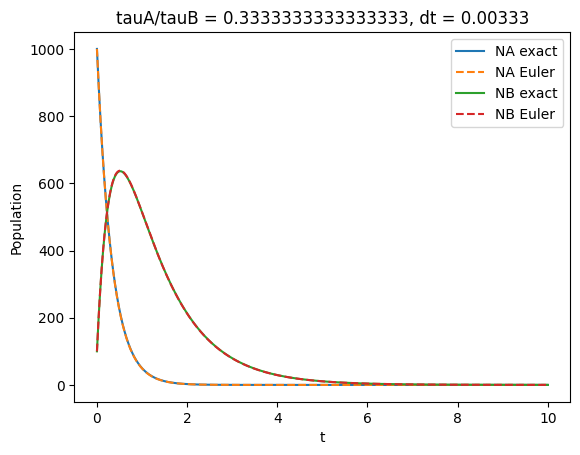

ratio=0.3333333333333333, dt=0.00333, max|NB err|=2.167e+00, dt/2 max|NB err|=1.081e+00, E1/E2 ~ 2.01


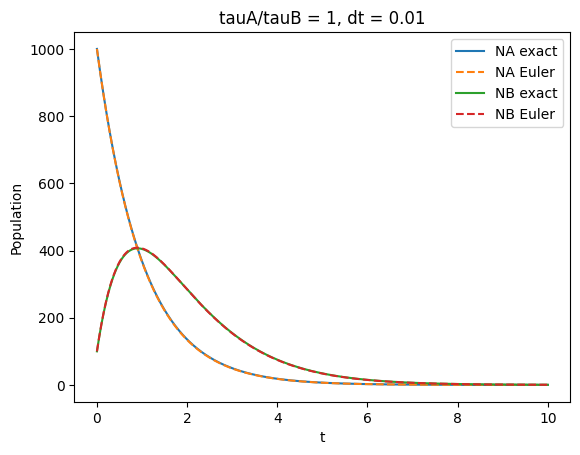

ratio=   1, dt=0.01, max|NB err|=2.161e+00, dt/2 max|NB err|=1.076e+00, E1/E2 ~ 2.01


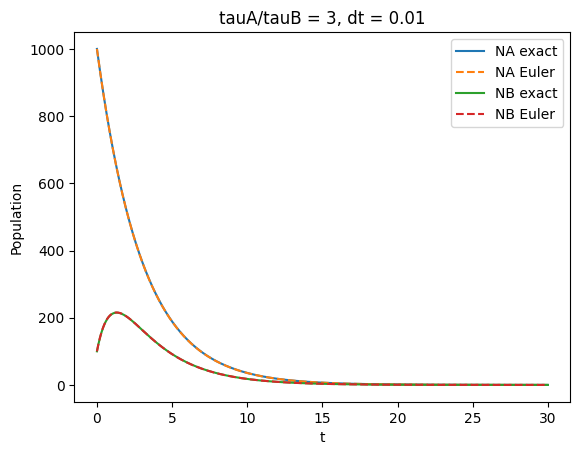

ratio=   3, dt=0.01, max|NB err|=5.520e-01, dt/2 max|NB err|=2.753e-01, E1/E2 ~ 2.01


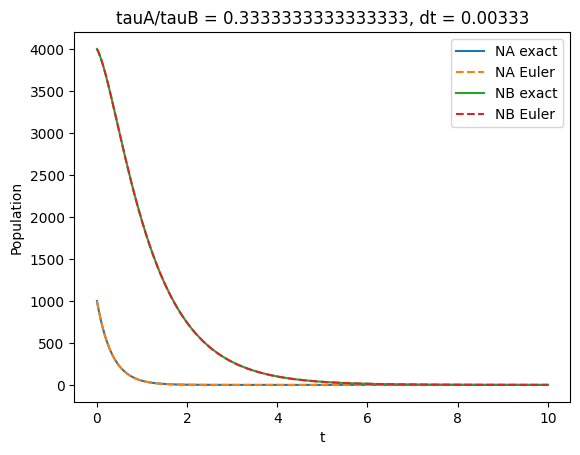

ratio=0.3333333333333333, dt=0.00333, max|NB err|=2.702e+00, dt/2 max|NB err|=1.350e+00, E1/E2 ~ 2.00


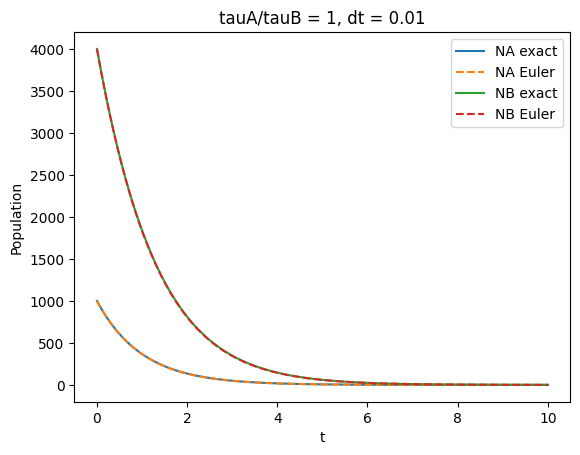

ratio=   1, dt=0.01, max|NB err|=5.889e+00, dt/2 max|NB err|=2.939e+00, E1/E2 ~ 2.00


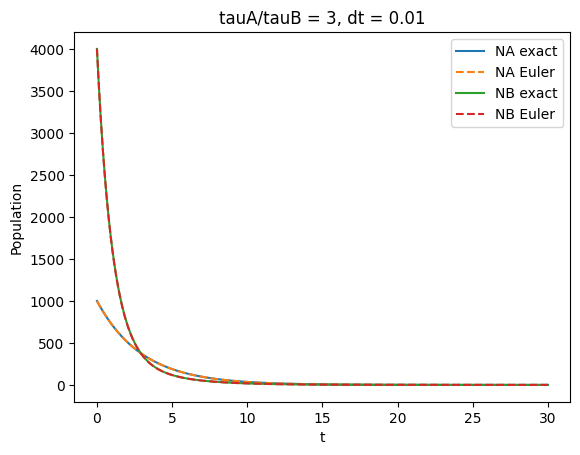

ratio=   3, dt=0.01, max|NB err|=6.665e+00, dt/2 max|NB err|=3.326e+00, E1/E2 ~ 2.00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def exact_solution (t, NA0, NB0, tauA, tauB):
    NA = NA0 * np.exp(-t / tauA);
    if abs(tauA - tauB) < 1e-12:
        tau = tauA;
        NB = (NB0 + (NA0 / tau) * t) * np.exp(-t / tau);
    else:
        NB = NB0 * np.exp(-t / tauB) + (NA0 * tauB / (tauA - tauB)) * (np.exp(-t / tauA) - np.exp(-t / tauB));

    return NA, NB;

def euler_decay(NA0, NB0, tauA, tauB, dt, tmax):
    # we WANT to overshoot a little like the slides says
    nsteps = int(np.ceil(tmax / dt));
    t = np.linspace(0.0, nsteps * dt, nsteps + 1);

    NA = np.zeros_like(t);
    NB = np.zeros_like(t);
    NA[0], NB[0] = NA0, NB0;

    for n in range(nsteps):
        NA[n+1] = NA[n] * (1.0 - dt / tauA);
        NB[n+1] = NB[n] * (1.0 - dt / tauB) + dt * (NA[n] / tauA);

    return t, NA, NB;

def run_case(ratio, NA0, NB0, tauB=1.0, dt_factor=0.01):
    tauA = ratio * tauB
    tmax = 10.0 * max(tauA, tauB)
    dt = dt_factor * min(tauA, tauB)

    # Euler
    t, NAe, NBe = euler_decay(NA0, NB0, tauA, tauB, dt, tmax)
    # Exact
    NAx, NBx = exact_solution(t, NA0, NB0, tauA, tauB)

    # Errors
    # errA = np.abs(NAe - NAx)
    # errB = np.abs(NBe - NBx)

    # Plots
    plt.figure()
    plt.plot(t, NAx, label="NA exact")
    plt.plot(t, NAe, "--", label="NA Euler")
    plt.plot(t, NBx, label="NB exact")
    plt.plot(t, NBe, "--", label="NB Euler")
    plt.xlabel("t")
    plt.ylabel("Population")
    plt.title(f"tauA/tauB = {ratio}, dt = {dt:.3g}")
    plt.legend()
    plt.show()

    # plt.figure()
    # plt.plot(t, errA, label="|NA error|")
    # plt.plot(t, errB, label="|NB error|")
    # plt.yscale("log")
    # plt.xlabel("t")
    # plt.ylabel("Absolute error (log scale)")
    # plt.title(f"Error vs time (tauA/tauB = {ratio})")
    # plt.legend()
    # plt.show()

    # Convergence check: dt vs dt/2 (max error ratio should be ~2 for Euler)
    t2, NAe2, NBe2 = euler_decay(NA0, NB0, tauA, tauB, dt/2, tmax)
    NAx2, NBx2 = exact_solution(t2, NA0, NB0, tauA, tauB)

    E1 = np.max(np.abs(NBe - NBx))
    E2 = np.max(np.abs(NBe2 - NBx2))
    print(f"ratio={ratio:>4}, dt={dt:.3g}, max|NB err|={E1:.3e}, "
          f"dt/2 max|NB err|={E2:.3e}, E1/E2 ~ {E1/E2:.2f}")

if __name__ == "__main__":
    # Two initial-condition regimes requested:
    # (1) NA0/tauA > NB0/tauB : B initially rises
    # (2) NA0/tauA < NB0/tauB : B initially falls

    ratios = [1/3, 1, 3]

    # Example A: NB0 small -> rising B initially
    for r in ratios:
        run_case(r, NA0=1000.0, NB0=100.0, tauB=1.0, dt_factor=0.01)

    # Example B: NB0 large -> falling B initially (for many ratios)
    for r in ratios:
        run_case(r, NA0=1000.0, NB0=4000.0, tauB=1.0, dt_factor=0.01)


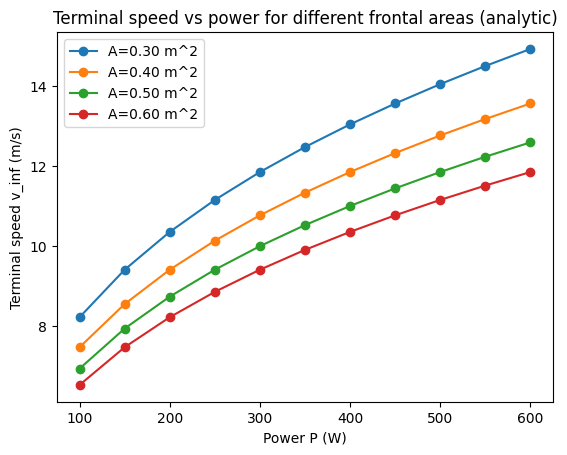

Check: P=300.0 W, A=0.5 m^2 -> v_inf numeric=10.000, analytic=10.000 m/s
dt check: dt=0.0100 -> 10.0000 m/s, dt/2=0.0050 -> 10.0000 m/s, diff=2.2400e-12 m/s
At v=13.0 m/s:
  Front: A=0.500 -> P_drag=659.1 W
  Pack : A=0.350 -> P_drag=461.4 W
  Savings = 30.0% (same % for energy over same time)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def terminal_speed_analytic(P, A, rho=1.2, C=1.0):
    # Closed-form terminal speed from dv/dt = 0
    return (2.0 * P / (C * rho * A)) ** (1.0 / 3.0)

def simulate_bike_euler(P, A, m=70.0, rho=1.2, C=1.0, v0=0.1, dt=0.01, tmax=200.0):
    # Euler integrate: dv/dt = (P/(m v)) - (C rho A v^2)/(2m). It returns t, v arrays.

    nsteps = int(np.ceil(tmax / dt))
    t = np.linspace(0.0, nsteps * dt, nsteps + 1)
    v = np.zeros_like(t)

    # Avoid divide-by-zero in P/(m v). Keep v positive.
    v[0] = max(v0, 1e-6)

    for n in range(nsteps):
        vn = max(v[n], 1e-6)
        dvdt = (P / (m * vn)) - (C * rho * A * vn * vn) / (2.0 * m)

        # next v should be nonnegative
        v[n + 1] = max(vn + dvdt * dt, 0.0)

    return t, v

def estimate_terminal_from_timeseries(t, v, tail_frac=0.10, method="mean"):
    """
    Robust terminal-speed estimate: average (or median) of the last tail_frac
    of the time series. This avoids declaring 'terminal' too early.
    """
    if len(v) < 10:
        return v[-1]

    k0 = int((1.0 - tail_frac) * len(v))
    tail = v[k0:]

    if method == "median":
        return float(np.median(tail))
    return float(np.mean(tail))

def power_required_at_speed(v, A, rho=1.2, C=1.0):
    # Drag-only power needed to hold constant speed v.
    return 0.5 * C * rho * A * v**3

if __name__ == "__main__":
    # --- Part 1: effect of P and A on ultimate velocity ---
    rho, C, m = 1.2, 1.0, 70.0
    A_values = [0.30, 0.40, 0.50, 0.60]          # m^2
    P_values = np.linspace(100, 600, 11)         # W

    plt.figure()
    for A in A_values:
        v_inf = [terminal_speed_analytic(P, A, rho=rho, C=C) for P in P_values]
        plt.plot(P_values, v_inf, marker="o", label=f"A={A:.2f} m^2")
    plt.xlabel("Power P (W)")
    plt.ylabel("Terminal speed v_inf (m/s)")
    plt.title("Terminal speed vs power for different frontal areas (analytic)")
    plt.legend()
    plt.show()

    # --- Numerical check against analytic for one case ---
    P_test, A_test = 300.0, 0.50
    dt_test = 0.01
    tmax_test = 200.0

    t, v = simulate_bike_euler(P_test, A_test, m=m, rho=rho, C=C, v0=0.1, dt=dt_test, tmax=tmax_test)
    v_num = estimate_terminal_from_timeseries(t, v, tail_frac=0.10, method="mean")
    v_an  = terminal_speed_analytic(P_test, A_test, rho=rho, C=C)
    print(f"Check: P={P_test} W, A={A_test} m^2 -> v_inf numeric={v_num:.3f}, analytic={v_an:.3f} m/s")

    # --- (Optional but good) dt adequacy check: halve dt ---
    t2, v2 = simulate_bike_euler(P_test, A_test, m=m, rho=rho, C=C, v0=0.1, dt=dt_test/2, tmax=tmax_test)
    v_num2 = estimate_terminal_from_timeseries(t2, v2, tail_frac=0.10, method="mean")
    print(f"dt check: dt={dt_test:.4f} -> {v_num:.4f} m/s, dt/2={dt_test/2:.4f} -> {v_num2:.4f} m/s, "
          f"diff={abs(v_num-v_num2):.4e} m/s")

    # --- Part 2: pack vs front energy at v = 13 m/s with 30% lower A in pack ---
    v_target = 13.0
    A_front = 0.50
    A_pack = 0.70 * A_front

    P_front = power_required_at_speed(v_target, A_front, rho=rho, C=C)
    P_pack  = power_required_at_speed(v_target, A_pack,  rho=rho, C=C)

    print(f"At v={v_target} m/s:")
    print(f"  Front: A={A_front:.3f} -> P_drag={P_front:.1f} W")
    print(f"  Pack : A={A_pack:.3f} -> P_drag={P_pack:.1f} W")
    print(f"  Savings = {(1 - P_pack/P_front)*100:.1f}% (same % for energy over same time)")



Best angle / max range (Euler):
T0=260.0 K | exp       | theta*= 40.0 deg | Rmax=10,114.5 m
T0=260.0 K | adiabatic | theta*= 40.0 deg | Rmax=10,099.9 m
T0=300.0 K | exp       | theta*= 37.0 deg | Rmax=7,697.4 m
T0=300.0 K | adiabatic | theta*= 36.0 deg | Rmax=7,569.5 m
T0=320.0 K | exp       | theta*= 36.0 deg | Rmax=6,788.5 m
T0=320.0 K | adiabatic | theta*= 35.0 deg | Rmax=6,653.8 m


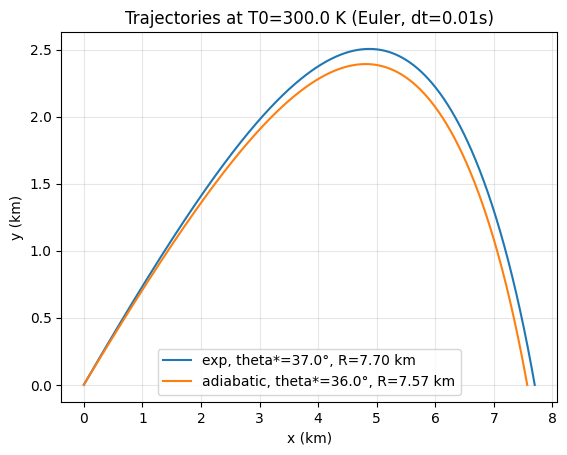

In [ ]:
# Cannon shell with quadratic drag + altitude-dependent density (Euler, simple)
# Compares: exponential rho = rho0*exp(-y/y0) vs adiabatic rho = rho0*(1 - a y/T0)^alpha
# Also allows temperature scaling: B2 = B2_ref*(T0/Tref)^alpha

import numpy as np
import matplotlib.pyplot as plt

g = 9.8

# Density models
def rho_ratio_exp (y, y0):
    return np.exp(-y / y0);

def rho_ratio_adiabatic (y, a, T0, alpha):
    base = 1.0 - (a * y / T0);
    return 0.0 if base <= 0.0 else base**alpha;

# One trajectory - Euler
def shoot_range(theta_deg, *, v0, m, B2_ref, T0, Tref, alpha_T, rho_model, dt, tmax, y0 = 1e4, a = 9.8e-3, alpha_atm = 2.5):
    # Returns: (range_x_hit, trajectory arrays x,y) for a launch angle. rho_model: "exp" or "adiabatic"
    theta = np.deg2rad(theta_deg);
    x, y = 0.0, 0.0;
    vx, vy = v0 * np.cos(theta), v0 * np.sin(theta);
    # Temperature scaling of drag coefficient
    B2 = B2_ref * (T0 / Tref)**alpha_T;
    xs = [x]; ys = [y];
    y_prev = y;
    nsteps = int(np.ceil(tmax / dt));
    for _ in range(nsteps):
        v = np.hypot(vx, vy);
        if rho_model == "exp":
            rr = rho_ratio_exp(y, y0);
        else:
            rr = rho_ratio_adiabatic(y, a, T0, alpha_atm);
        # accelerations (quadratic drag)
        ax = -(B2/m) * rr * v * vx;
        ay = -g - (B2/m) * rr * v * vy;
        # Euler update
        x += dt * vx; y += dt * vy; vx += dt * ax; vy += dt * ay;
        xs.append(x); ys.append(y);
        # Ground hit detection (after leaving ground)
        if (y_prev > 0.0) and (y <= 0.0):
            # linear interpolation to y=0 for better range
            x0, y0p = xs[-2], ys[-2];
            x1, y1p = xs[-1], ys[-1];
            lam = (0.0 - y0p) / (y1p - y0p);
            x_hit = x0 + lam * (x1 - x0);
            return x_hit, np.array(xs), np.array(ys);
        y_prev = y;
    # If it never hit within tmax, return last x (increase tmax if this happens)
    return xs[-1], np.array(xs), np.array(ys);

# HEAVY AI USE IN THIS FUNCTION!! MAPPING PHYSICS TO CODE IMPLEMENTATION WAS SUPER HARD FOR THIS ONE
def find_best_angle(*, angles_deg, **kwargs):
    best_R = -1.0;
    best_th = None;
    for th in angles_deg:
        R, _, _ = shoot_range(th, **kwargs);
        if R > best_R:
            best_R, best_th = R, th;
    return best_th, best_R;

# ---------- Demo / main ----------
if __name__ == "__main__":
    # ==== SET THESE FROM YOUR TEXT / Problem (values below are placeholders) ====
    v0 = 700.0       # m/s
    m  = 15.0        # kg
    B2_ref = 0.0039  # (text's quadratic drag constant at Tref; units per their convention)

    # Atmosphere params (typical book-ish values; use yours if given)
    y0 = 1.0e4       # m, scale height for exponential model
    a  = 9.8e-3      # K/m
    alpha_atm = 2.5  # 1/(gamma-1) with gamma=1.4

    # Temperature effect on drag coefficient
    Tref = 300.0
    alpha_T = alpha_atm  # per prompt: same alpha used in scaling

    # Numerical controls
    dt   = 0.01      # s  (halve this for adequacy check)
    tmax = 200.0     # s  (increase if shells don't land in time)

    # Angles to scan: 10 to 80 inclusive, step 1 degree
    angles = np.arange(10.0, 80.0 + 1e-12, 1.0)

    # Temperatures to compare
    temps = [260.0, 300.0, 320.0]  # winter, reference, summer

    results = []

    for T0 in temps:
        for model in ["exp", "adiabatic"]:
            th_star, R_star = find_best_angle(
                angles_deg=angles,
                v0=v0, m=m, B2_ref=B2_ref, T0=T0, Tref=Tref, alpha_T=alpha_T,
                rho_model=model, dt=dt, tmax=tmax,
                y0=y0, a=a, alpha_atm=alpha_atm
            )
            results.append((T0, model, th_star, R_star))

    print("\nBest angle / max range (Euler):")
    for T0, model, th, R in results:
        print(f"T0={T0:>5.1f} K | {model:9s} | theta*={th:5.1f} deg | Rmax={R:,.1f} m")

    # One representative trajectory plot at T0=300K using each model at its best angle
    T0_plot = 300.0
    for model in ["exp", "adiabatic"]:
        th_star = [r[2] for r in results if (abs(r[0]-T0_plot) < 1e-9 and r[1] == model)][0]
        R, xs, ys = shoot_range(
            th_star,
            v0=v0, m=m, B2_ref=B2_ref, T0=T0_plot, Tref=Tref, alpha_T=alpha_T,
            rho_model=model, dt=dt, tmax=tmax,
            y0=y0, a=a, alpha_atm=alpha_atm
        )
        plt.plot(xs/1000, ys/1000, label=f"{model}, theta*={th_star:.1f}°, R={R/1000:.2f} km")

    plt.xlabel("x (km)")
    plt.ylabel("y (km)")
    plt.title(f"Trajectories at T0={T0_plot} K (Euler, dt={dt}s)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# EOF
